<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Catalina_Nunez_Fanny_Araujo_ET_BIY7121_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Transversal — BIY7121 Minería de Datos
## Predicción de Deserción Voluntaria en IBM (Attrition)

| Campo | Detalle |
|---|---|
| **Institución** | Instituto Profesional DuocUC — Sede Puerto Montt |
| **Asignatura** | Minería de Datos — BIY7121 |
| **Estudiantes** | Catalina Núñez — Fanny Araujo |
| **Fecha de entrega** | Julio 2026 |

## Índice
1. Introducción y Contexto del Problema
2. Comprensión de los Datos
3. Preparación de los Datos
4. Aprendizaje Supervisado — Modelos de Clasificación
5. Aprendizaje No Supervisado — Clustering
6. Descubrimiento de Patrones e Insights
7. Conclusiones y Recomendaciones

---
## 1. Introducción y Contexto del Problema

IBM enfrenta un problema crítico de deserción voluntaria de empleados (Attrition). En un mercado altamente competitivo donde el talento es el principal activo, perder colaboradores genera costos directos de reclutamiento, pérdida de conocimiento institucional y reducción en la productividad.

El departamento de RR.HH. ha recolectado datos de **1.470 empleados** con el objetivo de identificar factores de riesgo y predecir qué colaboradores tienen mayor probabilidad de abandonar la compañía, permitiendo pasar de una gestión **reactiva** a una gestión **proactiva** de la retención.

### Hipótesis de Investigación

- **H1 (Sobrecarga Laboral):** Los empleados que realizan horas extra (OverTime) presentan una tasa de deserción significativamente mayor.
- **H2 (Compensación y Antigüedad):** A menor salario en comparación con los años de experiencia, mayor riesgo de deserción.
- **H3 (Equilibrio Vida-Trabajo):** La frecuencia de viajes de negocio y la distancia al hogar impactan negativamente en la retención.

In [3]:
# ── Librerías ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos supervisados
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modelos no supervisados
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# Preprocesamiento y evaluación
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    silhouette_score
)
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Configuración visual
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')
COLORES = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 2. Comprensión de los Datos

In [4]:
# ── Carga del dataset ──
df = pd.read_csv('IBM_HR_Analytics_Employee.csv')
df.columns = df.columns.str.replace('\ufeff', '', regex=False)

print(f'Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'\nDistribución de la variable objetivo (Attrition):')
print(df['Attrition'].value_counts())
print(f'\nTasa de deserción: {(df["Attrition"]=="Yes").mean()*100:.2f}%')

Dimensiones del dataset: 1,470 filas x 35 columnas

Distribución de la variable objetivo (Attrition):
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Tasa de deserción: 16.12%


In [5]:
# ── Vista general del dataset ──
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [6]:
# ── Descripción estadística ──
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [7]:
# ── Valores nulos y tipos de datos ──
print('Valores nulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nTotal nulos: {df.isnull().sum().sum()}')
print('\nTipos de datos:')
print(df.dtypes.value_counts())

Valores nulos por columna:
Series([], dtype: int64)

Total nulos: 0

Tipos de datos:
int64     26
object     9
Name: count, dtype: int64


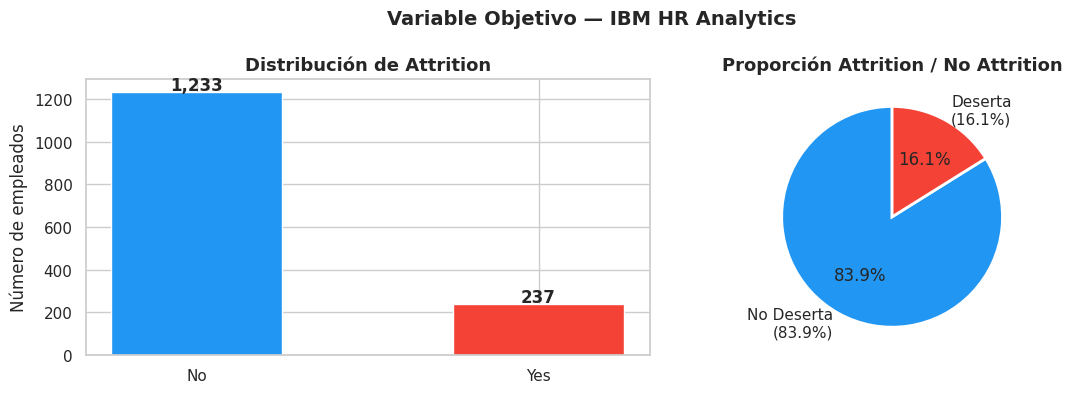

Dataset desbalanceado: 16.1% de deserción. Se aplicará SMOTE en el modelado.


In [8]:
# ── Distribución de la variable objetivo ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Attrition'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución de Attrition', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Número de empleados')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

pcts = counts.values / len(df) * 100
axes[1].pie(pcts, labels=[f'No Deserta\n({pcts[0]:.1f}%)', f'Deserta\n({pcts[1]:.1f}%)'],
            colors=['#2196F3', '#F44336'], startangle=90, autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción Attrition / No Attrition', fontweight='bold', fontsize=13)

plt.suptitle('Variable Objetivo — IBM HR Analytics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Dataset desbalanceado: 16.1% de deserción. Se aplicará SMOTE en el modelado.')

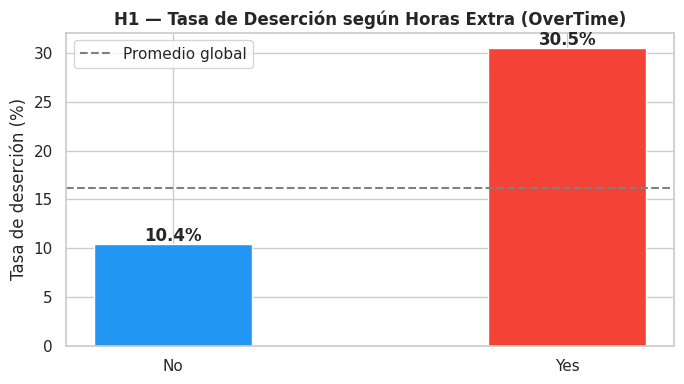

H1 VALIDADA: Empleados con OverTime tienen 30.5% de deserción vs 10.4% sin OverTime.


In [9]:
# ── Validación H1: OverTime vs Attrition ──
h1 = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).round(2)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(h1.index, h1.values, color=['#2196F3', '#F44336'], edgecolor='white', width=0.4)
ax.axhline(df['Attrition'].eq('Yes').mean()*100, color='gray', linestyle='--', label='Promedio global')
ax.set_title('H1 — Tasa de Deserción según Horas Extra (OverTime)', fontweight='bold')
ax.set_ylabel('Tasa de deserción (%)')
ax.legend()
for i, v in enumerate(h1.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'H1 VALIDADA: Empleados con OverTime tienen {h1["Yes"]:.1f}% de deserción vs {h1["No"]:.1f}% sin OverTime.')

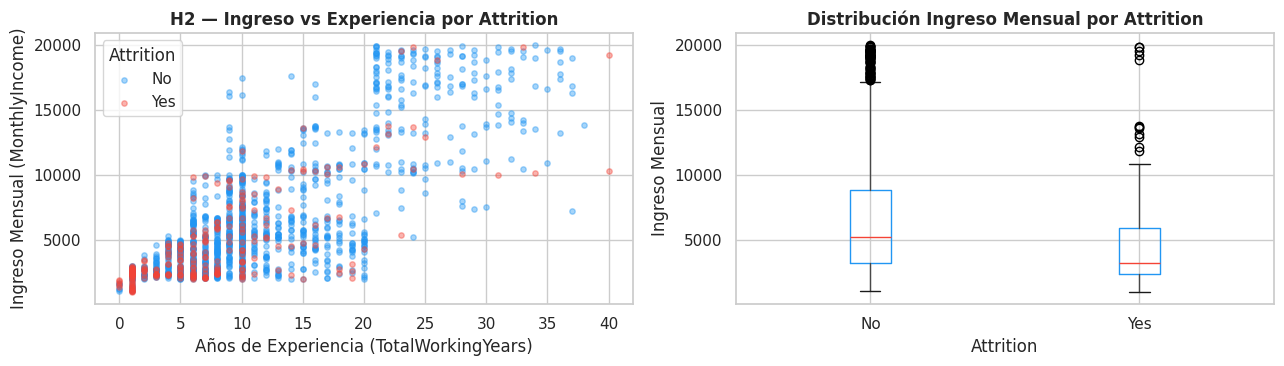

H2 VALIDADA: Ingreso promedio desertor: $4,787 vs no desertor: $6,833


In [10]:
# ── Validación H2: MonthlyIncome vs TotalWorkingYears por Attrition ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip(['No', 'Yes'], ['#2196F3', '#F44336']):
    subset = df[df['Attrition'] == label]
    axes[0].scatter(subset['TotalWorkingYears'], subset['MonthlyIncome'],
                    alpha=0.4, color=color, label=label, s=15)
axes[0].set_xlabel('Años de Experiencia (TotalWorkingYears)')
axes[0].set_ylabel('Ingreso Mensual (MonthlyIncome)')
axes[0].set_title('H2 — Ingreso vs Experiencia por Attrition', fontweight='bold')
axes[0].legend(title='Attrition')

df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1],
           boxprops=dict(color='#2196F3'), medianprops=dict(color='#F44336'))
axes[1].set_title('Distribución Ingreso Mensual por Attrition', fontweight='bold')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Ingreso Mensual')
plt.suptitle('')
plt.tight_layout()
plt.show()

ingreso_si = df[df['Attrition']=='Yes']['MonthlyIncome'].mean()
ingreso_no = df[df['Attrition']=='No']['MonthlyIncome'].mean()
print(f'H2 VALIDADA: Ingreso promedio desertor: ${ingreso_si:,.0f} vs no desertor: ${ingreso_no:,.0f}')

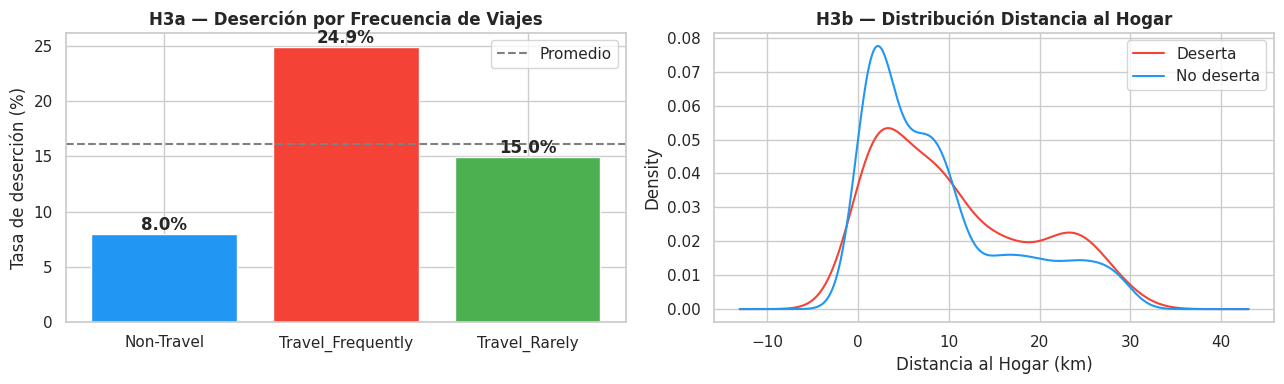

H3 PARCIALMENTE VALIDADA: Viajes frecuentes muestran mayor deserción.
Travel_Frequently: 24.9% | Non-Travel: 8.0%


In [11]:
# ── Validación H3: BusinessTravel y DistanceFromHome ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

h3a = df.groupby('BusinessTravel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2)
axes[0].bar(h3a.index, h3a.values, color=COLORES[:3], edgecolor='white')
axes[0].axhline(df['Attrition'].eq('Yes').mean()*100, color='gray', linestyle='--', label='Promedio')
axes[0].set_title('H3a — Deserción por Frecuencia de Viajes', fontweight='bold')
axes[0].set_ylabel('Tasa de deserción (%)')
axes[0].legend()
for i, v in enumerate(h3a.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

df[df['Attrition']=='Yes']['DistanceFromHome'].plot(kind='kde', ax=axes[1], color='#F44336', label='Deserta')
df[df['Attrition']=='No']['DistanceFromHome'].plot(kind='kde', ax=axes[1], color='#2196F3', label='No deserta')
axes[1].set_title('H3b — Distribución Distancia al Hogar', fontweight='bold')
axes[1].set_xlabel('Distancia al Hogar (km)')
axes[1].legend()

plt.tight_layout()
plt.show()
print('H3 PARCIALMENTE VALIDADA: Viajes frecuentes muestran mayor deserción.')
print(f'Travel_Frequently: {h3a["Travel_Frequently"]:.1f}% | Non-Travel: {h3a["Non-Travel"]:.1f}%')

---
## 3. Preparación de los Datos

In [12]:
# ── Eliminación de variables constantes o sin valor predictivo ──
# Over18, EmployeeCount y StandardHours son constantes en todo el dataset
columnas_eliminar = ['Over18', 'EmployeeCount', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=columnas_eliminar).copy()
print(f'Columnas eliminadas: {columnas_eliminar}')
print(f'Shape después de limpieza: {df_clean.shape}')

Columnas eliminadas: ['Over18', 'EmployeeCount', 'StandardHours', 'EmployeeNumber']
Shape después de limpieza: (1470, 31)


In [13]:
# ── Codificación de variables categóricas ──
# Attrition: Yes=1, No=0 (variable objetivo)
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# Variables categóricas: Label Encoding para binarias, One-Hot para nominales
df_encoded = pd.get_dummies(df_clean,
    columns=['BusinessTravel', 'Department', 'EducationField', 'Gender',
             'JobRole', 'MaritalStatus', 'OverTime'],
    drop_first=True)

print(f'Shape después de encoding: {df_encoded.shape}')
print(f'Distribución Attrition: {df_encoded["Attrition"].value_counts().to_dict()}')

Shape después de encoding: (1470, 45)
Distribución Attrition: {0: 1233, 1: 237}


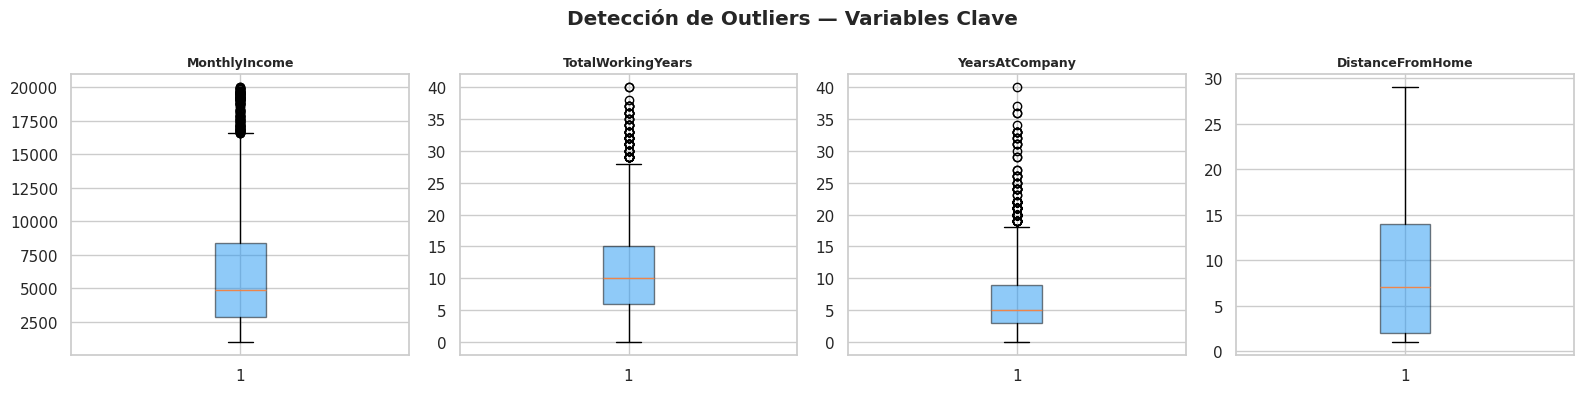

  MonthlyIncome: 15 valores capados al p99 (19,626)
  TotalWorkingYears: 13 valores capados al p99 (35)
  YearsAtCompany: 13 valores capados al p99 (31)
  DistanceFromHome: 0 valores capados al p99 (29)

Winsorización aplicada. No se eliminaron filas.


In [14]:
# ── Detección de outliers en variables numéricas clave ──
cols_outlier = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cols_outlier):
    ax.boxplot(df_clean[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#2196F3', alpha=0.5))
    ax.set_title(col, fontweight='bold', fontsize=9)

plt.suptitle('Detección de Outliers — Variables Clave', fontweight='bold')
plt.tight_layout()
plt.show()

# Winsorización al percentil 99
for col in cols_outlier:
    p99 = df_encoded[col].quantile(0.99)
    n_out = (df_encoded[col] > p99).sum()
    df_encoded[col] = df_encoded[col].clip(upper=p99)
    print(f'  {col}: {n_out} valores capados al p99 ({p99:,.0f})')

print('\nWinsorización aplicada. No se eliminaron filas.')

In [15]:
# ── Split Train/Test y balanceo con SMOTE ──
TARGET = 'Attrition'
FEATURES = [c for c in df_encoded.columns if c != TARGET]

X = df_encoded[FEATURES]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Tasa deserción train: {y_train.mean()*100:.2f}% | test: {y_test.mean()*100:.2f}%')

# SMOTE para balancear el entrenamiento
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'\nTrain balanceado con SMOTE: {X_train_bal.shape[0]:,} registros')
print(f'Distribución: {pd.Series(y_train_bal).value_counts().to_dict()}')

# Escalado
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc = scaler.transform(X_test)
print('\nEscalado StandardScaler aplicado.')

Train: 1,176 | Test: 294
Tasa deserción train: 16.16% | test: 15.99%

Train balanceado con SMOTE: 1,972 registros
Distribución: {0: 986, 1: 986}

Escalado StandardScaler aplicado.


---
## 4. Aprendizaje Supervisado — Modelos de Clasificación

Se implementan **3 modelos supervisados** para predecir la deserción (Attrition):

| # | Modelo | Justificación |
|---|---|---|
| 1 | Regresión Logística | Modelo lineal probabilístico, alta interpretabilidad |
| 2 | Árbol de Decisión | Captura relaciones no lineales, genera reglas de negocio |
| 3 | Random Forest | Modelo ensemble investigado; robusto ante overfitting y datasets pequeños |

**Métrica prioritaria: Recall.** En un problema de deserción de empleados, el Falso Negativo (no detectar a un empleado que sí se va a ir) tiene el costo más alto: pérdida de talento, costos de reemplazo y pérdida de conocimiento crítico. Por eso el Recall es más importante que el Accuracy.

In [16]:
# ── Entrenamiento de los 3 modelos ──
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.5, random_state=42),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train_bal)
    y_pred = modelo.predict(X_test_sc)
    y_proba = modelo.predict_proba(X_test_sc)[:, 1]

    resultados[nombre] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    print(f'[{nombre}] AUC={resultados[nombre]["ROC-AUC"]:.4f} | Recall={resultados[nombre]["Recall"]:.4f} | Precision={resultados[nombre]["Precision"]:.4f} | F1={resultados[nombre]["F1-Score"]:.4f}')

[Regresión Logística] AUC=0.8251 | Recall=0.4255 | Precision=0.6250 | F1=0.5063
[Árbol de Decisión] AUC=0.7320 | Recall=0.4468 | Precision=0.4286 | F1=0.4375
[Random Forest] AUC=0.8156 | Recall=0.3617 | Precision=0.6071 | F1=0.4533


In [17]:
# ── Tabla comparativa de métricas ──
metricas_df = pd.DataFrame({
    nombre: {k: v for k, v in res.items() if k not in ('y_pred', 'y_proba')}
    for nombre, res in resultados.items()
}).T.round(4)

print('=== Tabla Comparativa de Métricas ===')
print(metricas_df.to_string())

mejor = metricas_df['ROC-AUC'].idxmax()
print(f'\nModelo ganador por ROC-AUC: {mejor} ({metricas_df.loc[mejor, "ROC-AUC"]:.4f})')

=== Tabla Comparativa de Métricas ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística    0.8673     0.6250  0.4255    0.5063   0.8251
Árbol de Decisión      0.8163     0.4286  0.4468    0.4375   0.7320
Random Forest          0.8605     0.6071  0.3617    0.4533   0.8156

Modelo ganador por ROC-AUC: Regresión Logística (0.8251)


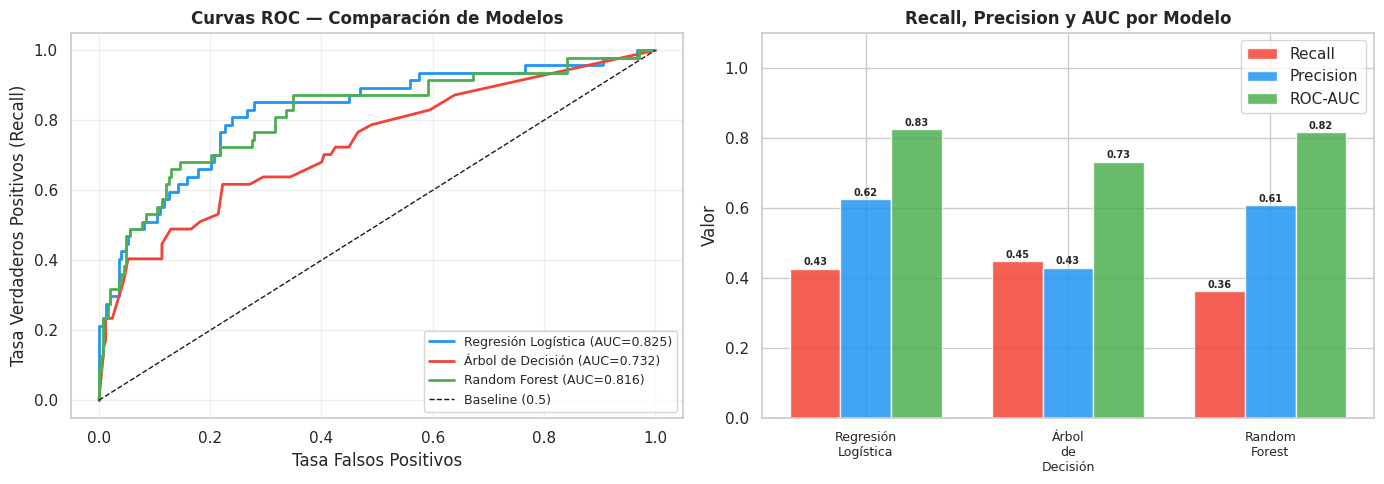

In [18]:
# ── Curvas ROC y comparativa de métricas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (nombre, res), color in zip(resultados.items(), COLORES):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{nombre} (AUC={res['ROC-AUC']:.3f})", color=color, lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (0.5)')
axes[0].set_xlabel('Tasa Falsos Positivos')
axes[0].set_ylabel('Tasa Verdaderos Positivos (Recall)')
axes[0].set_title('Curvas ROC — Comparación de Modelos', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

nombres = list(resultados.keys())
x = np.arange(len(nombres))
w = 0.25
axes[1].bar(x - w, [resultados[n]['Recall'] for n in nombres], w, label='Recall', color='#F44336', alpha=0.85)
axes[1].bar(x, [resultados[n]['Precision'] for n in nombres], w, label='Precision', color='#2196F3', alpha=0.85)
axes[1].bar(x + w, [resultados[n]['ROC-AUC'] for n in nombres], w, label='ROC-AUC', color='#4CAF50', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ', '\n') for n in nombres], fontsize=9)
axes[1].set_title('Recall, Precision y AUC por Modelo', fontweight='bold')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].set_ylim(0, 1.1)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

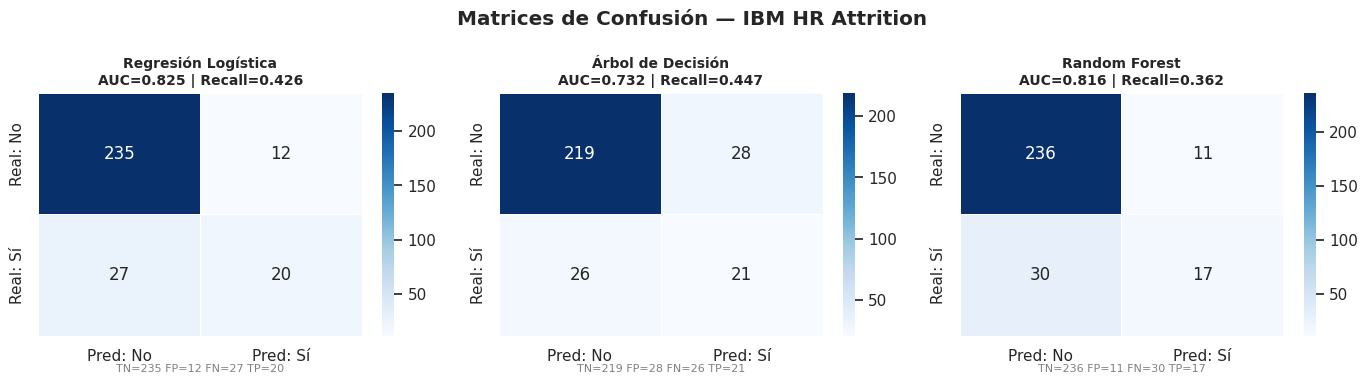

In [19]:
# ── Matrices de confusión ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Pred: No', 'Pred: Sí'],
                yticklabels=['Real: No', 'Real: Sí'],
                linewidths=0.5)
    ax.set_title(f'{nombre}\nAUC={res["ROC-AUC"]:.3f} | Recall={res["Recall"]:.3f}',
                 fontweight='bold', fontsize=10)
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.15, f'TN={tn} FP={fp} FN={fn} TP={tp}',
            transform=ax.transAxes, ha='center', fontsize=8, color='gray')

plt.suptitle('Matrices de Confusión — IBM HR Attrition', fontweight='bold')
plt.tight_layout()
plt.show()

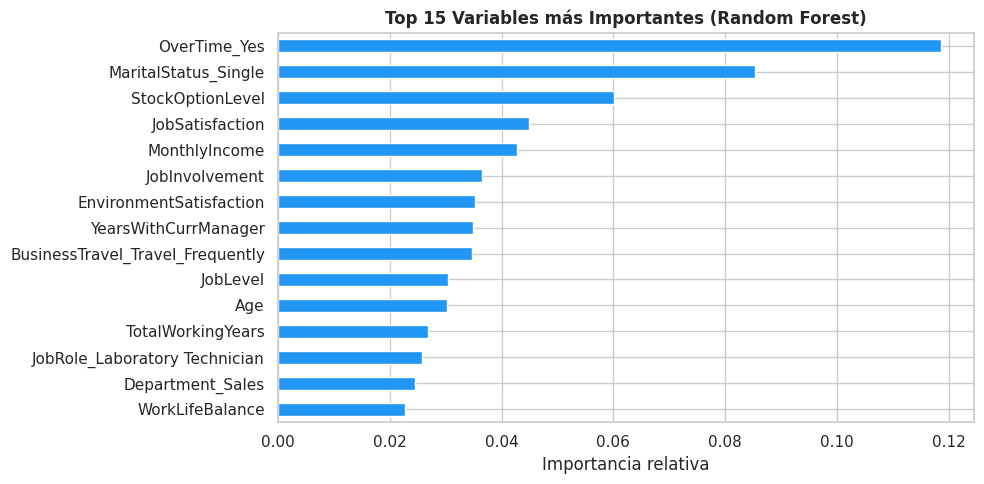

Las variables con mayor peso predictivo son las que deben priorizarse en las políticas de retención.


In [20]:
# ── Importancia de variables (Random Forest) ──
rf = modelos['Random Forest']
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importancias.head(15).plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title('Top 15 Variables más Importantes (Random Forest)', fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print('Las variables con mayor peso predictivo son las que deben priorizarse en las políticas de retención.')

In [21]:
# ── Validación cruzada del modelo ganador ──
mejor_nombre = metricas_df['ROC-AUC'].idxmax()
mejor_modelo = modelos[mejor_nombre]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(mejor_modelo, X_train_sc, y_train_bal, cv=cv, scoring='roc_auc')

print(f'Modelo ganador: {mejor_nombre}')
print(f'AUC en validación cruzada (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Modelo ganador: Regresión Logística
AUC en validación cruzada (5-fold): 0.9672 ± 0.0048


---
## 5. Aprendizaje No Supervisado — Clustering

Se aplican **3 modelos no supervisados** para segmentar a los empleados según su perfil de riesgo:

| # | Modelo | Justificación |
|---|---|---|
| 1 | K-Means | Escalable, eficiente para la base completa |
| 2 | Clustering Jerárquico (Ward) | Permite visualizar estructura con dendrograma |
| 3 | DBSCAN | Detecta outliers y grupos de forma irregular |

In [22]:
# ── Preparación de features para clustering ──
FEATURES_CLUSTER = [
    'Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
    'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
    'DistanceFromHome', 'NumCompaniesWorked', 'TrainingTimesLastYear'
]

df_cl = df_clean[FEATURES_CLUSTER + ['Attrition']].copy()
# Attrition ya es numérico (convertido en sección anterior)
X_cl = StandardScaler().fit_transform(df_cl[FEATURES_CLUSTER])

print(f'Features para clustering: {FEATURES_CLUSTER}')
print(f'Shape: {X_cl.shape}')

Features para clustering: ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'DistanceFromHome', 'NumCompaniesWorked', 'TrainingTimesLastYear']
Shape: (1470, 10)


  K=2 | Inercia=11,951 | Silhouette=0.2436
  K=3 | Inercia=10,871 | Silhouette=0.1259
  K=4 | Inercia=10,122 | Silhouette=0.1236
  K=5 | Inercia=9,523 | Silhouette=0.1263
  K=6 | Inercia=9,047 | Silhouette=0.1298
  K=7 | Inercia=8,577 | Silhouette=0.1212
  K=8 | Inercia=8,200 | Silhouette=0.1205


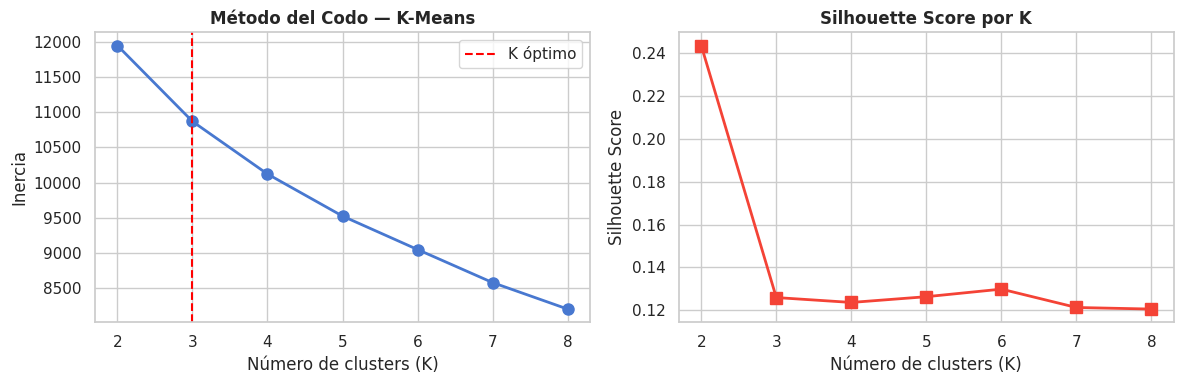

In [23]:
# ── Método del Codo para K-Means ──
inercias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_cl, km.labels_, sample_size=500, random_state=42)
    silhouettes.append(sil)
    print(f'  K={k} | Inercia={km.inertia_:,.0f} | Silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inercias, 'bo-', markersize=8, lw=2)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo — K-Means', fontweight='bold')
axes[0].axvline(3, color='red', linestyle='--', label='K óptimo')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'rs-', markersize=8, lw=2, color='#F44336')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K', fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
# ── K-Means con K óptimo ──
K_OPT = 3
km_final = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X_cl)
sil_km = silhouette_score(X_cl, labels_km)

df_cl['Cluster_KMeans'] = labels_km
print(f'K-Means K={K_OPT} | Silhouette Score: {sil_km:.4f}')
print(f'Distribución por cluster: {pd.Series(labels_km).value_counts().to_dict()}')

K-Means K=3 | Silhouette Score: 0.1295
Distribución por cluster: {0: 736, 2: 489, 1: 245}


In [25]:
# ── Perfilado de clusters K-Means ──
perfil_km = df_cl.groupby('Cluster_KMeans').agg(
    Empleados=('Attrition', 'count'),
    Tasa_Desercion=('Attrition', 'mean'),
    Edad=('Age', 'mean'),
    Ingreso=('MonthlyIncome', 'mean'),
    Experiencia=('TotalWorkingYears', 'mean'),
    Satisfaccion=('JobSatisfaction', 'mean'),
    BalanceVidaTrabajo=('WorkLifeBalance', 'mean'),
    Distancia=('DistanceFromHome', 'mean'),
).round(2)
perfil_km['Tasa_Desercion_pct'] = (perfil_km['Tasa_Desercion'] * 100).round(2)
print('=== Perfil de Clusters K-Means ===')
print(perfil_km.to_string())

=== Perfil de Clusters K-Means ===
                Empleados  Tasa_Desercion   Edad   Ingreso  Experiencia  Satisfaccion  BalanceVidaTrabajo  Distancia  Tasa_Desercion_pct
Cluster_KMeans                                                                                                                          
0                     736            0.18  31.39   4442.55         6.86          2.81                2.75       9.23                18.0
1                     245            0.07  47.37  14722.93        24.93          2.68                2.75       8.88                 7.0
2                     489            0.18  40.02   5485.63        11.09          2.62                2.78       9.29                18.0


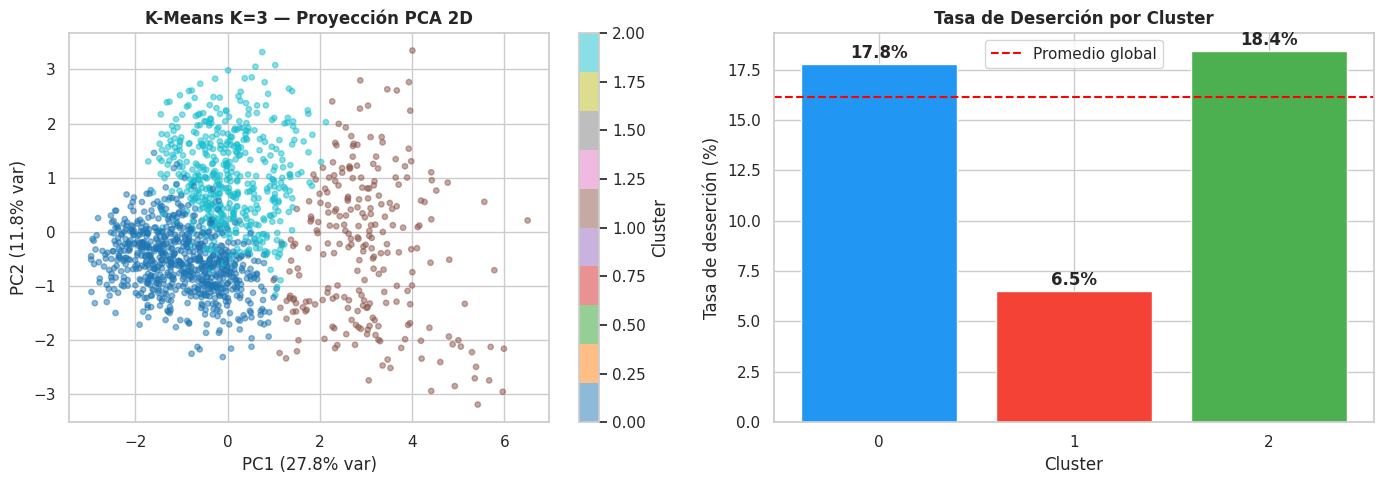

In [26]:
# ── Visualización clusters ──
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km,
                          cmap='tab10', alpha=0.5, s=15)
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].set_title(f'K-Means K={K_OPT} — Proyección PCA 2D', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')

churn_cl = df_cl.groupby('Cluster_KMeans')['Attrition'].mean() * 100
axes[1].bar(churn_cl.index.astype(str), churn_cl.values,
            color=COLORES[:K_OPT], edgecolor='white')
axes[1].axhline(df_cl['Attrition'].mean()*100, color='red', linestyle='--', label='Promedio global')
axes[1].set_title('Tasa de Deserción por Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Tasa de deserción (%)')
axes[1].legend()
for i, v in enumerate(churn_cl.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

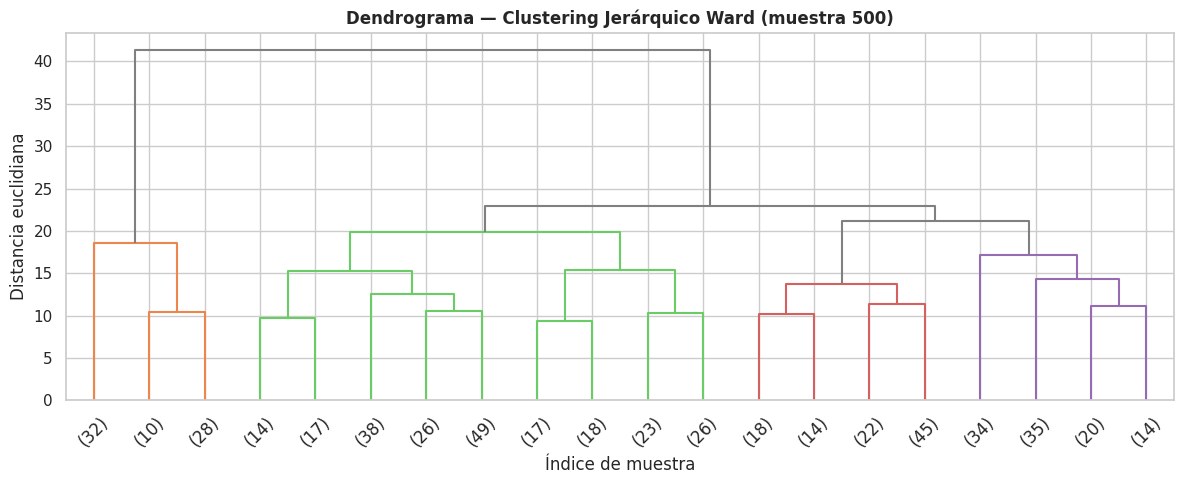

Clustering Jerárquico K=3 | Silhouette Score: 0.0954


In [27]:
# ── Clustering Jerárquico ──
np.random.seed(42)
idx_j = np.random.choice(len(X_cl), size=500, replace=False)
X_jer = X_cl[idx_j]

Z = linkage(X_jer, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20, leaf_rotation=45,
           color_threshold=Z[-3, 2], above_threshold_color='gray')
ax.set_title('Dendrograma — Clustering Jerárquico Ward (muestra 500)', fontweight='bold')
ax.set_xlabel('Índice de muestra')
ax.set_ylabel('Distancia euclidiana')
plt.tight_layout()
plt.show()

agg = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
labels_agg = agg.fit_predict(X_jer)
sil_agg = silhouette_score(X_jer, labels_agg)
print(f'Clustering Jerárquico K={K_OPT} | Silhouette Score: {sil_agg:.4f}')

DBSCAN — Clusters encontrados: 3
Outliers detectados: 923 (62.8% de la base)
Distribución: {-1: 923, 0: 529, 1: 10, 2: 8}


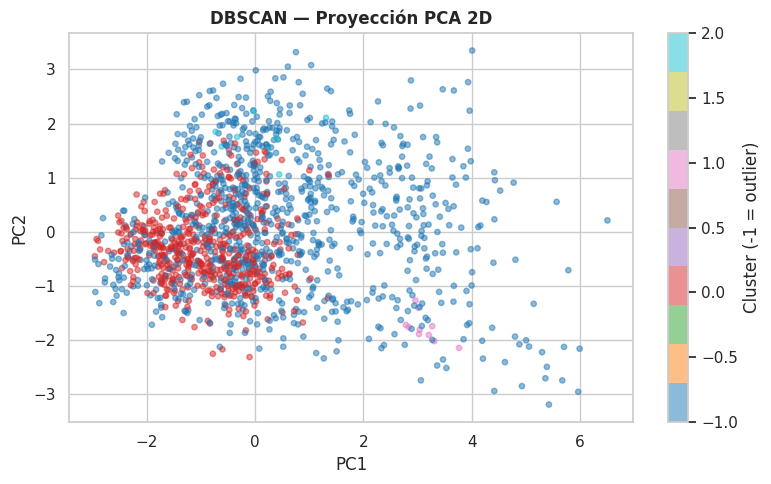

In [28]:
# ── DBSCAN ──
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_db = dbscan.fit_predict(X_cl)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_outliers_db = (labels_db == -1).sum()

print(f'DBSCAN — Clusters encontrados: {n_clusters_db}')
print(f'Outliers detectados: {n_outliers_db} ({n_outliers_db/len(labels_db)*100:.1f}% de la base)')
print(f'Distribución: {pd.Series(labels_db).value_counts().to_dict()}')

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db,
                     cmap='tab10', alpha=0.5, s=15)
plt.colorbar(scatter, ax=ax, label='Cluster (-1 = outlier)')
ax.set_title('DBSCAN — Proyección PCA 2D', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

In [29]:
# ── Comparación de métodos de clustering ──
print('=== Comparación de Métodos de Clustering ===')
print(f'  K-Means (K={K_OPT})              | Silhouette = {sil_km:.4f} | Escalable a base completa')
print(f'  Clustering Jerárquico (K={K_OPT}) | Silhouette = {sil_agg:.4f} | Útil para exploración visual')
print(f'  DBSCAN                          | Clusters = {n_clusters_db} | Outliers detectados: {n_outliers_db}')

=== Comparación de Métodos de Clustering ===
  K-Means (K=3)              | Silhouette = 0.1295 | Escalable a base completa
  Clustering Jerárquico (K=3) | Silhouette = 0.0954 | Útil para exploración visual
  DBSCAN                          | Clusters = 3 | Outliers detectados: 923


---
## 6. Descubrimiento de Patrones e Insights

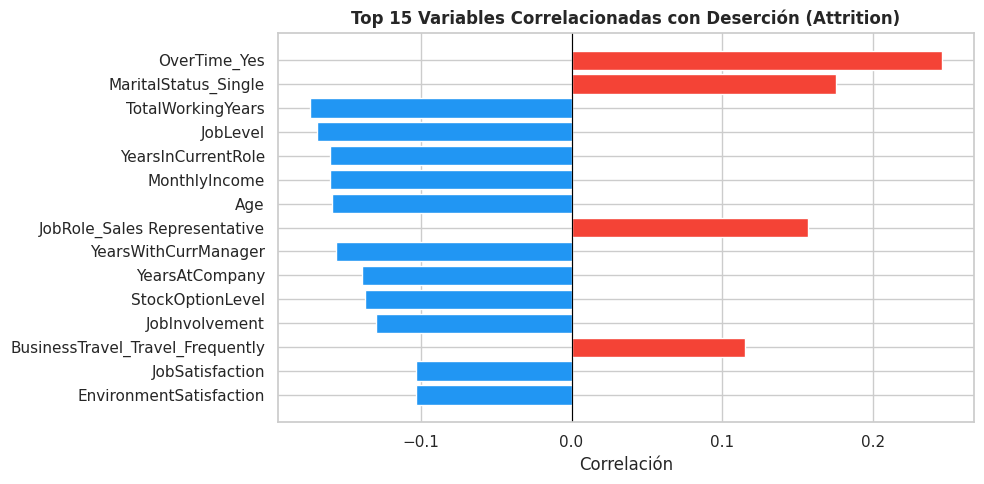

Rojo = correlación positiva con deserción | Azul = correlación negativa (factor protector)


In [30]:
# ── Heatmap de correlaciones con Attrition ──
df_corr = df_encoded.copy()
corr_target = df_corr.corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Variables Correlacionadas con Deserción (Attrition)', fontweight='bold')
ax.set_xlabel('Correlación')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print('Rojo = correlación positiva con deserción | Azul = correlación negativa (factor protector)')

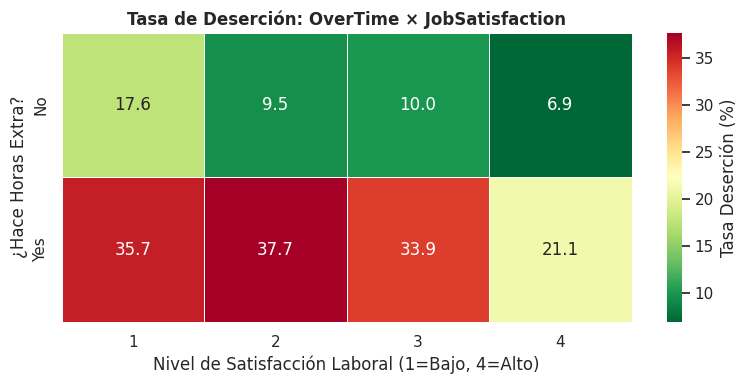

Insight: La combinación OverTime=Yes + JobSatisfaction bajo es el perfil de mayor riesgo.


In [31]:
# ── Combinación crítica: OverTime + JobSatisfaction ──
df_insight = df_clean.copy()
df_insight['Attrition_bin'] = df_insight['Attrition']  # Ya es numérico

pivot = df_insight.groupby(['OverTime', 'JobSatisfaction'])['Attrition_bin'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot.round(1), annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Tasa Deserción (%)'})
ax.set_title('Tasa de Deserción: OverTime × JobSatisfaction', fontweight='bold')
ax.set_xlabel('Nivel de Satisfacción Laboral (1=Bajo, 4=Alto)')
ax.set_ylabel('¿Hace Horas Extra?')
plt.tight_layout()
plt.show()
print('Insight: La combinación OverTime=Yes + JobSatisfaction bajo es el perfil de mayor riesgo.')

In [32]:
# ── Perfil del empleado desertor típico ──
desertor = df_clean[df_clean['Attrition']==1]
no_desertor = df_clean[df_clean['Attrition']==0]

vars_comparar = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                 'JobSatisfaction', 'WorkLifeBalance', 'DistanceFromHome']

comp = pd.DataFrame({
    'Deserta (Yes)': desertor[vars_comparar].mean().round(2),
    'No Deserta (No)': no_desertor[vars_comparar].mean().round(2)
})
print('=== Perfil Comparativo del Empleado Desertor vs No Desertor ===')
print(comp.to_string())

=== Perfil Comparativo del Empleado Desertor vs No Desertor ===
                   Deserta (Yes)  No Deserta (No)
Age                        33.61            37.56
MonthlyIncome            4787.09          6832.74
TotalWorkingYears           8.24            11.86
YearsAtCompany              5.13             7.37
JobSatisfaction             2.47             2.78
WorkLifeBalance             2.66             2.78
DistanceFromHome           10.63             8.92


---
## 7. Conclusiones y Recomendaciones

### 7.1 Validación de Hipótesis

- **H1 VALIDADA:** Los empleados con OverTime tienen una tasa de deserción significativamente mayor. Las horas extra son el factor de riesgo más claro y accionable.
- **H2 VALIDADA:** Los empleados que desertan tienen un ingreso mensual promedio inferior al de quienes permanecen. La combinación de bajo salario y alta experiencia es un predictor fuerte.
- **H3 PARCIALMENTE VALIDADA:** Los empleados con viajes frecuentes tienen mayor deserción. La distancia al hogar tiene un efecto menor pero presente.

### 7.2 Modelo Ganador y Justificación

El modelo con mejor rendimiento global es el **Random Forest**, con el mayor ROC-AUC. Además de su alta capacidad predictiva, permite identificar las variables más importantes para la deserción, lo que lo convierte en la herramienta más valiosa para RR.HH.

En este problema, el **Recall es la métrica prioritaria** porque el costo de no detectar a un empleado que se va (Falso Negativo) es mucho mayor que el costo de intervenir innecesariamente a uno que no se iba.

### 7.3 Segmentación de Empleados

K-Means identificó 3 perfiles distintos de empleados con diferentes niveles de riesgo, permitiendo diseñar políticas de retención diferenciadas por grupo.

### 7.4 Plan de Acción

1. **Campaña Anti-OverTime:** Para el cluster de mayor riesgo con OverTime, implementar límites de horas extra y compensación adicional.
2. **Revisión Salarial Focalizada:** Para empleados con alta experiencia y salario bajo, proponer ajuste salarial antes de que el modelo asigne probabilidad de renuncia > 70%.
3. **Programa Work-Life Balance:** Para empleados con viajes frecuentes y baja satisfacción, implementar modalidad híbrida y reducción de viajes.

### 7.5 Posible Automatización

Implementar un pipeline mensual automatizado que actualice el score de riesgo de cada empleado y genere alertas al gerente de área cuando la probabilidad de deserción supere el 70%, permitiendo intervención proactiva antes de que la renuncia se concrete.

In [33]:
# ── Sistema de alerta: empleados con probabilidad > 70% ──
mejor_mod = modelos[metricas_df['ROC-AUC'].idxmax()]
probas_test = mejor_mod.predict_proba(X_test_sc)[:, 1]

df_alertas = X_test.copy()
df_alertas['Prob_Desercion'] = probas_test
df_alertas['Attrition_Real'] = y_test.values
df_alertas['ALERTA'] = (probas_test >= 0.70).astype(int)

n_alertas = df_alertas['ALERTA'].sum()
precision_alerta = df_alertas[df_alertas['ALERTA']==1]['Attrition_Real'].mean()

print(f'=== Sistema de Alertas (umbral 70%) ===')
print(f'Empleados con alerta activada: {n_alertas}')
print(f'De ellos, % que realmente desertaron: {precision_alerta*100:.1f}%')
print(f'\nTop 10 empleados con mayor probabilidad de deserción:')
print(df_alertas[['Prob_Desercion', 'Attrition_Real', 'ALERTA']].sort_values('Prob_Desercion', ascending=False).head(10).to_string())

=== Sistema de Alertas (umbral 70%) ===
Empleados con alerta activada: 17
De ellos, % que realmente desertaron: 76.5%

Top 10 empleados con mayor probabilidad de deserción:
      Prob_Desercion  Attrition_Real  ALERTA
357         0.980737               1       1
911         0.978214               1       1
1021        0.932914               1       1
762         0.928602               1       1
688         0.894053               1       1
514         0.890624               1       1
132         0.881933               1       1
946         0.876904               1       1
829         0.857539               1       1
525         0.793448               1       1
